**Fastrek Bengkod - Danendra Farrel Haryo Wibowo - A11.2023.15025**

Import Library

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from imblearn.over_sampling import SMOTE

import joblib
import warnings
warnings.filterwarnings('ignore')

# masukin data dan menghapus identifier yang nggk punya nilai analitik
df = pd.read_csv('Bengkod-Depresi.csv')
df.drop('id', axis=1, inplace=True)


EDA

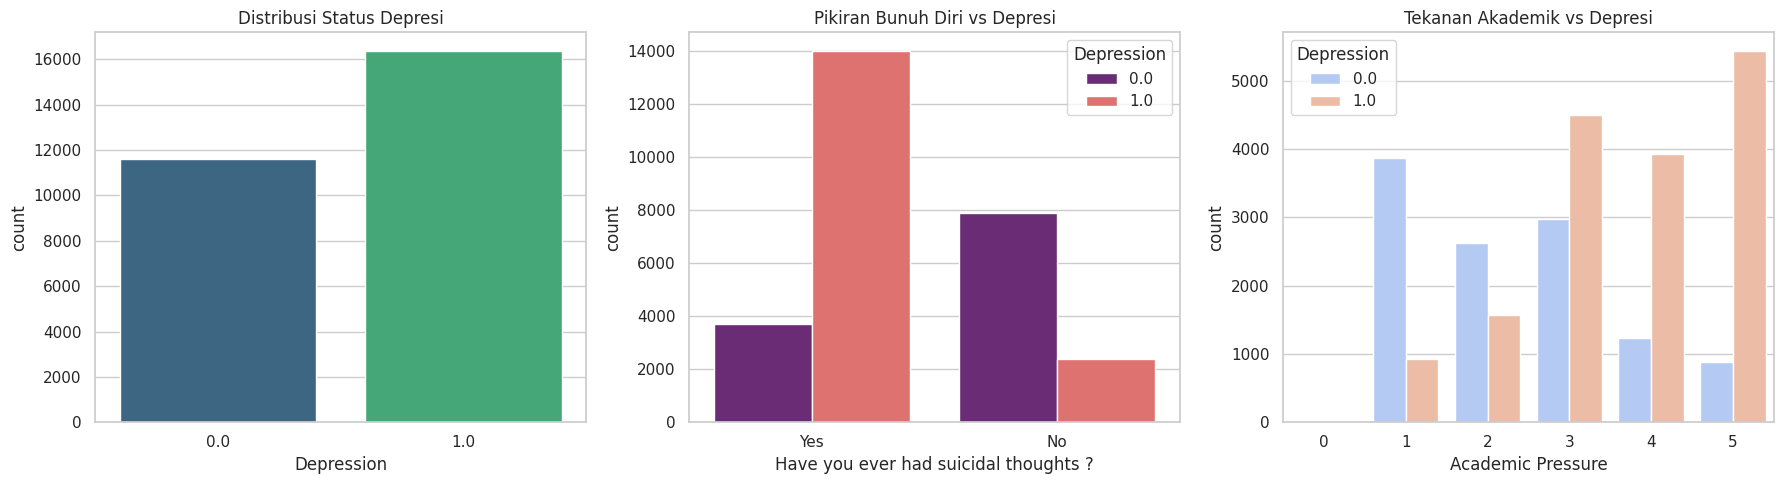

In [13]:
sns.set_theme(style="whitegrid")

# area gambar untuk 3 grafik berdampingan
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# grafik 1: jumlah mahasiswa yang Depresi dan Tidak
sns.countplot(x='Depression', data=df, palette='viridis', ax=axes[0])
axes[0].set_title('Distribusi Status Depresi')

# grafik 2: hubungan antara pikiran bunuh diri dengan depresi
sns.countplot(x='Have you ever had suicidal thoughts ?', hue='Depression', data=df, palette='magma', ax=axes[1])
axes[1].set_title('Pikiran Bunuh Diri vs Depresi')

# grafik 3: hubungan antara tekanan akademik dengan depresi
sns.countplot(x='Academic Pressure', hue='Depression', data=df, palette='coolwarm', ax=axes[2])
axes[2].set_title('Tekanan Akademik vs Depresi')
plt.tight_layout()
plt.show()

Direct Modeling (Data Kotor)

In [14]:
# encoding huruf ke angka
df_kotor = df.copy()

# ngilangin baris dengan nilai NaN sebelum encode
df_kotor.dropna(inplace=True)

label_encoders = {}
for col in df_kotor.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df_kotor[col] = le.fit_transform(df_kotor[col].astype(str))
    label_encoders[col] = le

X_kotor = df_kotor.drop('Depression', axis=1)
y_kotor = df_kotor['Depression']

X_train_ktr, X_test_ktr, y_train_ktr, y_test_ktr = train_test_split(X_kotor, y_kotor, test_size=0.2, random_state=42)

# Definisi 5 Model
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "SVM": SVC(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

print("--- Akurasi Direct Modeling (Data Kotor) ---")
acc_direct = {}
for name, model in models.items():
    model.fit(X_train_ktr, y_train_ktr)
    acc_direct[name] = accuracy_score(y_test_ktr, model.predict(X_test_ktr))
    print(f"{name}: {acc_direct[name]:.4f}")

--- Akurasi Direct Modeling (Data Kotor) ---
Logistic Regression: 0.8434
Decision Tree: 0.7558
SVM: 0.8427
Random Forest: 0.8371
Gradient Boosting: 0.8418


Modeling dengan Preprocessing (data bersih)


--- Akurasi Setelah Preprocessing (Data Bersih) ---
Logistic Regression: 0.8421
Decision Tree: 0.7642
SVM: 0.8398
Random Forest: 0.8335
Gradient Boosting: 0.8407


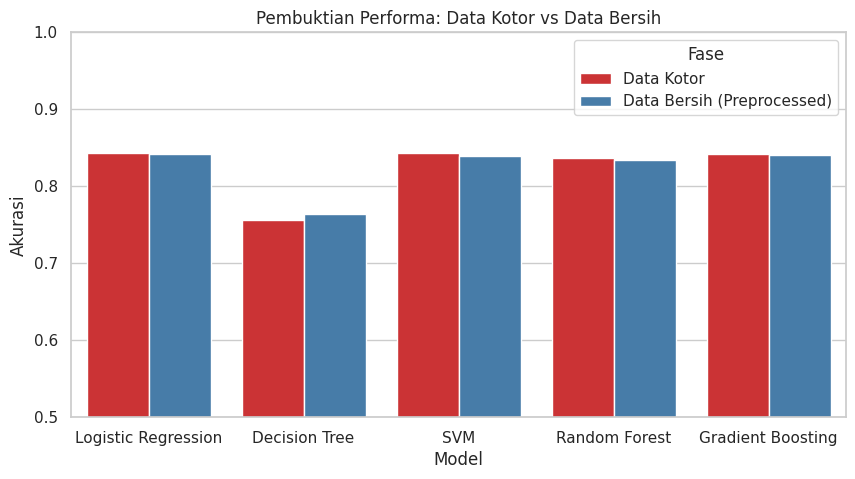

In [15]:
# preprocessing 1: Penyeimbangan data menggunakan SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_ktr, y_train_ktr)

# preprocessing 2: Standarisasi rentang nilai (Scaling)
scaler = StandardScaler()
X_train_bersih = scaler.fit_transform(X_train_smote)
X_test_bersih = scaler.transform(X_test_ktr)

print("\n--- Akurasi Setelah Preprocessing (Data Bersih) ---")
acc_bersih = {}
for name, model in models.items():
    model.fit(X_train_bersih, y_train_smote)
    acc_bersih[name] = accuracy_score(y_test_ktr, model.predict(X_test_bersih))
    print(f"{name}: {acc_bersih[name]:.4f}")

# visualisasi Komparasi Fase Kotor vs Bersih
df_compare = pd.DataFrame({
    'Model': list(models.keys()) * 2,
    'Akurasi': list(acc_direct.values()) + list(acc_bersih.values()),
    'Fase': ['Data Kotor'] * 5 + ['Data Bersih (Preprocessed)'] * 5
})

plt.figure(figsize=(10, 5))
sns.barplot(data=df_compare, x='Model', y='Akurasi', hue='Fase', palette='Set1')
plt.title('Pembuktian Performa: Data Kotor vs Data Bersih')
plt.ylim(0.5, 1)
plt.show()

In [16]:
print(X_train_ktr.columns.tolist())

['Gender', 'Age', 'City', 'Profession', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Work/Study Hours', 'Financial Stress', 'Family History of Mental Illness']


Feature Selection

In [17]:
# pemilihan 10 fitur terbaik pakek uji statistik
selector = SelectKBest(score_func=f_classif, k=14)
X_train_final = selector.fit_transform(X_train_bersih, y_train_smote)
X_test_final = selector.transform(X_test_bersih)

print("\n10 Fitur Terpilih.")


10 Fitur Terpilih.


Hyperparameter Tuning & Deployment


Akurasi Final Puncak : 0.8425
Settingan: {'solver': 'saga', 'max_iter': 1000, 'C': 1}
------------------------------


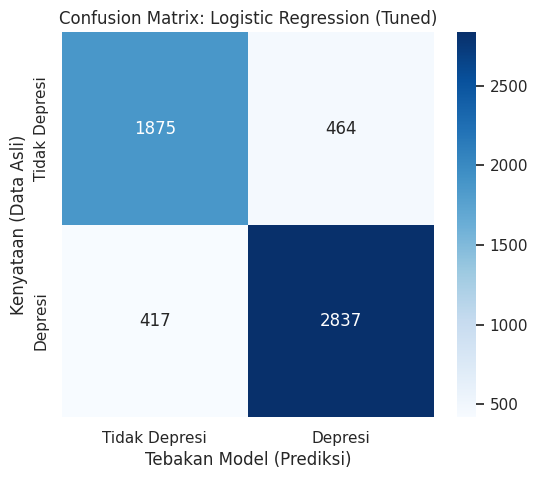

Model Logistic Regression disimpan sebagai model utama.


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score
import joblib

# --- best model LOGISTIC REGRESSION ---

# 1. nentuin kombinasi parameter Logistic Regression
param_grid_lr = {
    'C': [0.1, 1, 10, 100],          # ngatur kekuatan regulasi
    'solver': ['liblinear', 'saga'], # algoritma pencarian
    'max_iter': [1000, 2000]         # batas iterasi
}

# 2. RandomizedSearchCV untuk nyacari settingan paling akurat
best_model_search = RandomizedSearchCV(
    LogisticRegression(random_state=42),
    param_distributions=param_grid_lr,
    n_iter=8, cv=5, scoring='accuracy', random_state=42
)

# 3. Latih pada data yang sudah diseleksi (10 fitur)
best_model_search.fit(X_train_final, y_train_smote)
model_pemenang = best_model_search.best_estimator_

# 4. pengujian akhir untuk ngeliat akurasi
y_pred_final = model_pemenang.predict(X_test_final)
akurasi_puncak = accuracy_score(y_test_ktr, y_pred_final)

print(f"Akurasi Final Puncak : {akurasi_puncak:.4f}")
print(f"Settingan: {best_model_search.best_params_}")
print("-" * 30)

#visualisasi
# Menghitung nilai matriks
cm = confusion_matrix(y_test_ktr, y_pred_final)

# Membuat plot
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Tidak Depresi', 'Depresi'],
            yticklabels=['Tidak Depresi', 'Depresi'])
plt.title('Confusion Matrix: Logistic Regression (Tuned)')
plt.xlabel('Tebakan Model (Prediksi)')
plt.ylabel('Kenyataan (Data Asli)')
plt.show()

# --- DEPLOYMENT ---
# simpan Logistic Regression
joblib.dump(model_pemenang, 'model_depresi_final.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(selector, 'feature_selector.pkl')
joblib.dump(label_encoders, 'label_encoders.pkl')

print("Model Logistic Regression disimpan sebagai model utama.")

**Perbandingan Akurasi (Data Kotor vs. Data Bersih) :**


**Akurasi Data Kotor :**
    
    Logistic Regression: 0.8434, Decision Tree: 0.7558, SVM: 0.8427, Random Forest: 0.8371, Gradient Boosting: 0.8418

**Akurasi Data Bersih :**
  
    Logistic Regression: 0.8421, Decision Tree: 0.7642, SVM: 0.8398, Random Forest: 0.8335, Gradient Boosting: 0.8407


**Kesimpulan :**

**Fase Data Kotor :**

    data target belum bisa diseimbangkan (imbalanced). Hal ini menyebabkan model bias terhadap kelas mayoritas, dan juga dikarenakan perbedaan skala numerik antar fitur yang belum dinormalisasi. dan data yang kotor ini terbukti mengandung banyak noise yang seharusnya ini memang diobuang saja agar model dapat berjalan secara efektif serta efisien

**Fase Data Bersih :**

    Penggunaan teknik SMOTE untuk menyeimbangkan target dan Scaling untuk menyamakan skala fitur secara faktual, disini kita bisa lihat bahwasannya data yang sudah dibersihkan memiliki tingkat akurasi yang hampir sama dengan data kotor, disini membuktikan bahwasannya data kotor memang banyak noise yang harusnya dihilangkan dan walaupun sedikit lebih rendah tingkat akurasinya tetapi data yang bersih ini jauh lebih baik daripada data kotor karna model dapat bekerja secara efektif karna tidak perlu membuang energy untuk fitur fitur noise

**Pemilihan Model :**
    
    Didapati Logistik Regresi sebagai model terbaik dikarenakan memiliki tingkat akurasi yang paling tinggi di antara model model lain setelah data dibersihkan